# STRATA — Esqueleto razonado del TFG

**Qué es este documento.** Un **mapa**: recorre el trabajo entero en orden y, para cada pieza,
deja escrito *qué hago*, *qué decidí*, *por qué* y *qué objeción del tutor cubre*. No calcula nada
nuevo —las cifras se citan del notebook canónico `strata_canonical.ipynb` (§0–§14) y de
`outputs/experiments/*.json`—; existe para que **nada quede sin atar** y para que el tribunal no me
pille con un "¿y esto por qué?".

> **STRATA en una frase.** Es un *supervisor estadístico* que vigila, en tiempo de ejecución, las
> decisiones de un agente de trading basado en LLMs sobre SPY. **No predice el retorno de mañana:
> decide una posición para hoy** corrigiendo al agente cuando contradice al régimen de mercado.

**Idea ancla (repetir hasta que sea automática).** La aportación es el **rigor**, no el dinero. La
métrica primaria es la **accuracy direccional** (acertar el signo), no el Sharpe. Y todo va
**pre-registrado antes de mirar los datos**, para que no haya p-hacking.

### La hipótesis falsable (en 3 niveles)
1. **Estadístico:** filtrar/atenuar al agente con detectores clásicos lo **rescata** cuando pierde
   y acierta < 50 %. Contraste: **McNemar pareado** M8 vs M5.
2. **Mecánico:** el rescate se **atribuye** a los detectores (se espera que RAM domine).
3. **Universalidad:** un meta-learner (XGBoost-CPCV, M10) **no debe batir** a la regla a mano (M8)
   en P&L, y **SHAP** debe señalar las features de STRATA como las informativas.

Cualquier resultado contrario se reporta. La regla **prior-flip** (el signo del régimen en
calibración ≠ el signo en OOS) es un **mecanismo de falsificación pre-registrado**: documenta cuándo
la técnica NO funciona.

### Índice
0. Cómo leer esto · 1. Problema e hipótesis · 2. Universo y datos · 3. Los tres detectores ·
4. Decisiones de calibración · 5. La mecánica de un día · 6. Las estrategias comparadas ·
7. Los tests estadísticos · 8. Validación y robustez · 9. Resultados clave ·
**10. Mapa objeción-del-tutor → respuesta** · 11. Honestidad y límites · 12. Reproducibilidad.

## 1. El problema y la hipótesis

**El problema.** Un agente LLM (AI Hedge Fund: 5 personalidades — Buffett, Wood, Druckenmiller,
Burry, Ackman — agregadas por un *portfolio manager*) decide cada día *long/short* sobre SPY. Es un
**perdedor direccional**: acierta el signo el **38.4 %** de los días, *por debajo del azar* (canónico
§8; sign test $p<10^{-5}$ contra 0.5). Esa es la premisa del TFG, no un accidente.

**La idea de STRATA.** No reemplazar al agente ni predecir el mercado, sino **supervisarlo**: si su
decisión contradice el régimen estadístico del mercado, se atenúa o se corrige. Es una función
$f:(\text{tupla del agente}, \text{estado del mercado}) \to \text{tupla supervisada}$.

**Cómo se vuelve falsable** (lo que el tutor exige: *"¿cómo es significativo lo que presentas?"*):
cada cifra lleva test + criterio numérico **pre-registrado** en `BITACORA.md` antes de ver
resultados, y una **regla de fracaso** (prior-flip). Así, "funciona" o "no funciona" se decide con
una regla escrita de antemano, no a posteriori.

> **Cubre la objeción nº1 del tutor:** *"Tener un Sharpe positivo no demuestra nada sin fundamento.
> ¿Cómo validas? Parece que vendes humo. Necesitas rigor matemático."* → cada afirmación tiene H0,
> test, p-valor/IC y criterio pre-registrado (§7 y §12 de este mapa).

## 2. Universo y datos — las decisiones de partida

| Decisión | Cuál | Por qué | Objeción que cubre |
|---|---|---|---|
| **Activo central** | SPY (ETF del S&P 500) | *Leverage effect* (Black 1976; Christie 1982): en índices, alta volatilidad ⇒ régimen bajista, así que el HMM de volatilidad funciona como **proxy direccional**. En acciones sueltas con leverage débil no se cumple → limitación documentada. | "¿generaliza?" (→ se acota a SPY + panel de robustez en apéndice) |
| **Calibración** | 2000-01-01 → 2024-09-30 (24 años) | Suficiente para estabilidad; incluye 2008/2020/2022 (crisis reales). HMM/GARCH/BOCPD se entrenan **una sola vez** aquí. | "¿estable estructuralmente?" |
| **OOS (test)** | 2024-10-01 → cierre (~18 meses) | Inicio **posterior al cutoff de DeepSeek V3** (jul–oct 2024) → elimina contaminación *look-ahead* del LLM (no puede "recordar" esas fechas). | look-ahead del LLM |
| **Causalidad** | `signal_lag=1`: $w_t\cdot r_{t+1}$ | La posición de hoy multiplica el retorno de **mañana**, nunca el de hoy. El bug $w_t\cdot r_t$ (look-ahead de 1 día) infectó el proyecto anterior; aquí hay un test en CI que lo prohíbe. | *"la IA dice algo para mañana… no lo hagas contemporáneo"* |
| **Barrera temporal** | calib.max() < 2024-10-01 ≤ oos.min() | Sin solape entre calibración y test; los umbrales se fijan a 2024-09-30. | fuga calibración→test |

**Doble protocolo de control** (canónico §2): se reporta el Sharpe *same-day* (sanity) y el *causal*
(el único válido). **Aquí el signo se invierte entre ambos** (M5 causal $-1.82$ vs same-day $+0.88$) y
hay que saber defenderlo, porque parece el síntoma del bug $w_t\cdot r_t$. El argumento ganador: un
look-ahead **INFLA** el causal (lo haría parecer mejor); aquí el causal está **PENALIZADO** respecto
al same-day → va en **sentido contrario** a un leak. Es una propiedad del agente perdedor (correlaciona
con $r_t$ pero falla con $r_{t+1}$). Además, `tests/test_no_leakage.py` corre en CI y falla si se cuela
look-ahead. → **cubre la objeción** *"esa inversión, ¿no es contaminación?"*

## 3. Los tres detectores — qué mira STRATA

Tres detectores **ortogonales** (miran ejes distintos del mercado), cada uno con un modelo clásico:

| Detector | Eje | Pregunta | Modelo | Resumen matemático |
|---|---|---|---|---|
| **RAM** | Régimen discreto | ¿La acción es coherente con el régimen? | HMM gaussiano 3 estados | $P(s_t\mid x_{1:t})$ por *forward* causal; $x_t=[\,r_t,\ \text{vol}_{21d}\,]$ |
| **PSA** | Coherencia temporal del agente | ¿Está cambiando de opinión de forma estructural? | BOCPD (Adams & MacKay 2007) | posterior bayesiano sobre la *longitud de racha* del sizing |
| **GSO** | Volatilidad continua | ¿El tamaño es compatible con la vol? | GARCH(1,1)-t | $\sigma_t^2=\omega+\alpha\,\epsilon_{t-1}^2+\beta\,\sigma_{t-1}^2$, con $\alpha+\beta<1$ |

**HMM gaussiano** (RAM). Modela el mercado como una cadena de Markov oculta con $K$ regímenes; cada
régimen emite $(r,\text{vol})$ con su media y covarianza. Se ajusta por Baum-Welch (EM) y se usa el
**posterior filtrado** $\gamma^f_t=P(s_t\mid x_{1:t})$, que solo usa el pasado (Rabiner 1989,
*forward algorithm*). El RAM score = masa de probabilidad sobre el régimen **incompatible** con la
acción del agente.

**GARCH(1,1)-t** (GSO). La volatilidad de hoy depende del shock y la vol de ayer; las innovaciones
son $t$ de Student (colas pesadas, realistas). La condición $\alpha+\beta<1$ garantiza varianza
finita. Se usa $\sigma_t$ previsto a un paso (causal) para la banda de sizing.

**BOCPD** (PSA). Detección bayesiana *online* de puntos de cambio: mantiene la distribución de
"¿cuántos días llevo en la misma racha?" y sube cuando el sizing del agente cambia de estructura.
Se usa el **incremento** `cp_prob_delta` (el *momento* del cambio), no el nivel absoluto.

*(Definiciones en `core/hmm.py`, `core/garch.py`, `core/bocpd.py`; detectores en `strata/detectors.py`.)*

## 4. Decisiones de calibración (lo aprendido del histórico, sin mirar el futuro)

Todo esto se decide **solo con 2000–2024-09**. Cada decisión, con su porqué y la objeción que cubre.

### 4.1 ¿Cuántos regímenes? **K = 3** (Calma / Estrés / Crisis)
- **El criterio de selección es FUNCIONAL** (interpretabilidad + abstención), NO la verosimilitud.
  Razón: la verosimilitud held-out es **monótona en K** (K=4 mejora a K=3 en **14/16** orígenes), así
  que "maximizar verosimilitud" pediría K≥4 sin fin → no sirve para *elegir* K.
- **La verosimilitud se usa solo para CONFIRMAR que el 3er estado es estructura real, no relleno:**
  K=3 mejora a K=2 en **15/16 orígenes** (canónico §3; walk-forward Parte A), incluidas 2008/2020/2022.
- **Por qué 3 y no 4:** Calma/Estrés/Crisis son **nombrables** (relato económico) y el estado
  **Estrés = abstención** (RAM no interviene ahí → evita sobre-intervenir). K≥4 subdivide la
  volatilidad sin relato. Es un supervisor, no un ajustador de curvas.
- **Objeción que cubre:** *"¿por qué K=3 y no K=4, si K=4 da mejor verosimilitud?"* → concedo que K=4
  tiene mejor verosimilitud; el K se fija por **criterio de información vs criterio funcional**, y
  elijo el funcional. (canónico §3 y §12.)

### 4.2 El umbral de RAM: **τ = 0.5** (regla de mayoría)
- **Cómo se decide:** el histograma de $P(\text{Calma})$ es **bimodal** (masa en ≈0 y ≈1, valle casi
  vacío: el score es cuasi-binario) y el acierto direccional es **plano** para cualquier
  $\tau\in[0.3,0.9]$. Se adopta $\tau=0.5$ = "interviene si el régimen contrario es el más probable".
- **Por qué es defendible:** tiene **varianza de estimación nula** (no se estima de los datos, es la
  regla de Bayes) y el resultado es **robusto** a la posición del umbral (solo ~11/401 días caen en
  la zona intermedia). El tutor mismo propuso un **árbol de decisión de profundidad 1 + histograma
  coloreado** por el signo de $r_{t+1}$: ambos están en el canónico §4 y confirman el corte.
- **Objeción que cubre:** *"τ=0.5 lo elegiste tú a mano… eso al tribunal es peligroso"* → se enseña
  el histograma + el árbol, y se reporta el McNemar **también** con $\tau=0.40$ (robustez al umbral).

### 4.3 Umbrales de PSA y GSO: **percentiles P95 / P99** de la calibración
- Son detectores de **alarma para patologías raras** (cambio brusco de sizing, sobre-exposición). El
  codo donde la distribución deja de ser ruido y empieza la anomalía real está en la cola → P95/P99.
- Salen de los datos, sin ver el OOS. (canónico §4.)

### 4.4 Régimen **filtrado** (causal), no suavizado
- `hmmlearn` por defecto da el posterior *suavizado* (forward-**backward**), que usa el futuro →
  look-ahead. STRATA usa `predict_proba_filtered` (solo *forward*). **Objeción que cubre:** look-ahead.

### 4.5 Prior de RAM **data-driven por activo**
- El sentido permitido (Calma→long, Crisis→short en SPY) sale del **signo de la media de retorno por
  régimen en calibración**, no está hardcodeado. En activos con leverage invertido el signo se
  reasigna (p. ej. NVDA). **Objeción que cubre:** *"¿por qué Crisis→short universal?"*

## 5. La mecánica de un día (cómo se decide la posición)

Para que se vea que no hay magia (canónico §5, ejemplo verificable con calculadora):

```
1. El agente decide:         acción ∈ {long, short}, tamaño ∈ [0,1], confianza
2. Régimen filtrado:         γ^f_t = P(Calma), P(Estrés), P(Crisis)   (solo pasado)
3. Volatilidad prevista:     σ_t  (GARCH, a un paso, causal)
4. Detectores:               RAM = P(régimen contrario);  PSA = cp_prob_delta;  GSO = banda σ
5. ¿Interviene?              sí, si severidad RAM ≥ medium  (medium = τ = 0.5)
6. Override-C:               w_t = signo_régimen · min(1, σ*/σ_t)     [σ* = 10% objetivo]
7. P&L causal:               pnl_{t+1} = w_t · r_{t+1}                 (signal_lag = 1)
```

El paso 6 es el "**rescate**": cuando el agente va a contra-régimen, su posición se sustituye por la
del régimen, dimensionada por *volatility targeting* (banda GARCH). Los tres modos posibles son
`warn` (solo registra), `reduce` (atenúa) y `override` (sustituye); el canónico usa **override-C**.

> **Cubre:** *"quiero un ejemplo día a día, paso a paso"* y *"no lo hagas contemporáneo"* (paso 7).

## 6. Las estrategias comparadas (el roster y qué aísla cada una)

Todas devuelven **el mismo objeto**: una posición $w_t\in[-1,+1]$ → comparables día a día.

| Modelo | Qué es | Para qué está |
|---|---|---|
| **M5** | El agente solo (sin supervisar) | Línea base: la premisa "agente perdedor" |
| **M7** | STRATA `reduce` (atenúa sin voltear, gated en τ) | Aísla cuánto del rescate es **reducir tamaño** vs **corregir dirección** |
| **M8** | STRATA `override-C` (la regla a mano) | El supervisor canónico (white box, interpretable) |
| **M10** | XGBoost-CPCV sobre 22 features (15 del agente + 7 de STRATA) | El meta-learner aprendido; ¿bate a la regla o la redescubre? |
| **M2** | Régimen×GARCH **sin agente** | Ablación: ¿vale el régimen solo, sin el agente? |
| **M_neg** | El agente invertido (−agente) | ¿STRATA es algo más que "negar al agente"? |
| **B&H / always-short / coin-flip** | Baselines triviales | Suelo contra el que situar todo (B&H acc = 0.569) |

La **escalera M5 → M7 → M8** ordena la intensidad de intervención; **M10** y **M2** son los
contrastes que blindan contra "lo hace un modelo cualquiera" y "vale solo el régimen".

> **Cubre:** *"un XGBoost con todo dentro nunca va a salir peor que tu regla a mano"* → se compara
> explícitamente M10 vs M8 (§7, Diebold-Mariano + SHAP).

## 7. Los tests estadísticos — qué hacen y por qué ese (el corazón del rigor)

**Cómo leer cada test.** Un contraste tiene una **hipótesis nula $H_0$** (lo "aburrido": no hay
efecto) y una **alternativa $H_1$** (lo que quiero demostrar). El $p$-valor mide *cómo de sorprendentes
serían los datos si $H_0$ fuera cierta*. **Rechazar $H_0$** (cuando $p<\alpha$) = los datos son
incompatibles con "no hay efecto" → hay evidencia de $H_1$. **No rechazar** ≠ "$H_0$ es cierta": solo
"no hay evidencia suficiente". Uso $\alpha=0.10$ (pre-declarado, por la baja potencia con $N\approx400$).
Implementados en `core/stats.py` / `core/cpcv.py`.

### 7.1 McNemar pareado — *¿STRATA cambia el acierto direccional del agente?*
Sobre los **mismos días**, mira solo los **discordantes**: $b$ = M5 acierta y M8 falla; $c$ = M5 falla
y M8 acierta (los empates no informan).
- **$H_0$:** $P(b)=P(c)$ — M8 y M5 aciertan por igual; STRATA no cambia nada.
- **$H_1$:** $P(b)\neq P(c)$ — uno acierta más en los días en que difieren.
- **Rechazar $H_0$ ⇒** STRATA **sí** altera el acierto del agente de forma sistemática (no por azar);
  con $c>b$ eso es **rescate**.
- Estadístico $\chi^2=\dfrac{(|b-c|-1)^2}{b+c}$ (Edwards), **binomial exacto** si $b+c<25$.
- **Por qué:** pareado (mismos días) → mucha más potencia que comparar dos accuracies sueltas; mide
  *acierto* (métrica primaria). **Resultado:** M8 vs M5 $p=0.069$ ($\tau$) / 0.088 → **rechaza a
  $\alpha=0.10$** (hay rescate); *borderline* a 0.05. **Cubre:** *"¿es significativo?"*

### 7.2 Sign test — *¿el agente acierta distinto del azar?*
- **$H_0$:** $p_{\text{acierto}}=0.5$ (es una moneda). **$H_1$:** $p\neq0.5$.
- **Rechazar $H_0$ ⇒** el agente NO es azar. Binomial exacto a dos colas (Conover 1999) + IC
  Clopper-Pearson.
- **Resultado:** M5 rechaza **por debajo** (acc 0.384, $p<10^{-5}$) → **perdedor sistemático** (la
  premisa del TFG). **Cubre:** "el agente es malo de verdad, no por mala suerte".

### 7.3 Diebold-Mariano — *¿dos estrategias rinden igual en P&L?*
Serie de diferencia diaria $d_t = L^A_t-L^B_t$ con pérdida $L=-r$.
- **$H_0$:** $\mathbb E[d_t]=0$ — rinden igual en P&L. **$H_1$:** $\mathbb E[d_t]\neq0$ — una rinde más.
- **Rechazar $H_0$ ⇒** una estrategia bate a la otra. $\mathrm{DM}=\bar d/\sqrt{s_d^2/n}\sim\mathcal N(0,1)$.
- **Resultado:** M10 vs M8 $p=0.67$ → **NO se rechaza** → indistinguibles en P&L. *Ojo:* "no rechazar"
  no prueba que sean iguales (para eso, TOST). **Cubre:** *"el XGBoost debería batir a tu regla a mano"*.

### 7.4 TOST (equivalencia, Schuirmann 1987) — *¿M10 y M8 son equivalentes dentro de un margen $\delta$?*
Aquí las hipótesis van **al revés** (lo que quiero demostrar es la igualdad):
- **$H_0$:** $|\Delta|\ge\delta$ — son **distintas**. **$H_1$:** $|\Delta|<\delta$ — equivalentes.
- **Rechazar $H_0$ ⇒** declarar **equivalencia** formal.
- **Resultado:** $p=0.42$ → **NO se rechaza** → no se demuestra equivalencia (poca potencia, $N\approx400$).
  Honesto: digo "no distinguibles", no "probadas iguales".

### 7.5 Bootstrap estacionario (Politis-Romano 1994) — *¿el rescate en Sharpe es robusto?*
Remuestrea **bloques** de longitud media $\sqrt N$ (preserva la autocorrelación) y da el IC de la
mediana de $\Delta$Sharpe. Es el **test confirmatorio** del walk-forward; se usa como contraste:
- **$H_0$:** mediana $\Delta$Sharpe $\le 0$ (STRATA no mejora el P&L). **$H_1$:** $>0$.
- **Rechazar $H_0$ ⇒** el IC **excluye el 0 por abajo** → rescate económico robusto.
- **Resultado:** la cota inferior (con corrección Bonferroni por 2 contrastes) es **$<0$** → **NO se
  rechaza** → el rescate en Sharpe **no es robusto**. **Cubre:** IC honesto en series dependientes.

### 7.6 Deflated Sharpe (López de Prado 2014) — *¿el Sharpe sobrevive a haber probado muchas cosas?*
**No es un $p$-valor con $H_0/H_1$**: es una **probabilidad**, $DSR=P(\text{Sharpe verdadero}>0)$ tras
descontar el nº de configuraciones probadas ($n_{\text{trials}}$). Convence si es **alto** (p. ej.
$>0.95$). **Resultado:** con $n_{\text{trials}}=50$ da $\approx\mathbf{0.08}$ → casi seguro el Sharpe
es **azar**. **Cubre:** *"¿data-snooping con el Sharpe?"* → por eso la evidencia es el McNemar, no el Sharpe.

### 7.7 Block-permutation — *¿la diferencia de acierto es real o artefacto de autocorrelación?*
- **$H_0$:** M8 y M5 son **intercambiables** por bloques (mismo acierto). **$H_1$:** no lo son.
- **Rechazar $H_0$ ⇒** la diferencia de acierto es **real**, no un espejismo de la dependencia temporal.
- Permuta etiquetas A/B por bloques $\sqrt N$. **Resultado:** M10 vs M5 en bajista $p=0.061$ → rechaza a
  $\alpha=0.10$. Blinda al McNemar cuando los días no son independientes.

---
**Lo siguiente NO son contrastes de hipótesis** (no tienen $H_0/H_1$): son una corrección, una cantidad,
un esquema de validación o un criterio. Conviene tenerlo claro para no confundir al tribunal.

### 7.8 Holm-Bonferroni — *corrección de multiplicidad (no es un test)*
Cuando hago **varios** contrastes (p. ej. McNemar por régimen), ajusta los $p$-valores paso a paso para
controlar el error familiar (FWER). "**Sobrevivir Holm**" = un contraste sigue significativo **después**
de la corrección. **Cubre:** *"probaste muchos cortes, ¿no es p-hacking?"*

### 7.9 N efectivo de Bartlett (1946) — *una cantidad, no un test*
Tamaño muestral **efectivo** bajo autocorrelación: $N_{\text{eff}}=N\frac{1-\hat\rho}{1+\hat\rho}$.
Sirve para **no** contar 57 ventanas solapadas como 57 datos. **Cubre:** *"¿el 73.7% de ventanas no es
evidencia?"* → con $\rho\approx0.98$, $N_{\text{eff}}\approx0.6$: descriptivo, no prueba.

### 7.10 CPCV — *esquema de validación sin fuga, no un test* (López de Prado 2018, §7.4)
*Combinatorial Purged Cross-Validation*: $\binom{6}{2}=15$ particiones; **purga** del train los eventos
que solapan con el test y añade **embargo = 5** días; $t_1=\text{índice}.shift(-1)$ (etiqueta hoy =
retorno mañana). **Cubre:** *"KFold está sesgado en series temporales"*.

### 7.11 TreeSHAP — *atribución de importancia, no un test*
Reparte la predicción entre las features (Shapley exacto para árboles, Lundberg 2017); $|SHAP|$ medio
*out-of-fold*. **Resultado:** top-5 = `ram_score`, `garch_sigma`, `psa_score`, `crisis_prob`,
`stress_prob` (**ninguna personalidad**) → el meta-learner **redescubre** STRATA; la señal es de STRATA
(la ablación lo confirma: quitarlas tumba a M10, $+0.64\to+0.21$). **Detalle defensivo:** el tutor
**predijo** que SHAP coronaría las probabilidades del agente; el resultado es **el contrario** → su
propia predicción, comprobada, juega a favor.

### 7.12 Held-out likelihood — *criterio de selección de modelo, no un test*
Verosimilitud por observación del HMM ajustado en $[0,a)$ y evaluado en el bloque posterior $[a,b)$:
**mayor LL/obs = describe mejor los datos no vistos**. Confirma que K=3 mejora a K=2 (§4.1). No tiene
$p$-valor; es comparativo entre modelos. **Cubre:** *"¿de dónde sale K=3?"*

## 8. Validación y robustez — la respuesta a *"¿tuviste suerte con el periodo?"*

El tutor fue literal: *"lánzalo en diferentes años, en diferentes momentos; puede que tuvieras suerte
en el periodo que lanzaste"*. La validación (canónico §13) se parte en **dos** por un límite duro:

> ⚠ **LÍMITE CLAVE.** El agente LLM **solo existe en el OOS** (~18 meses); no hay decisiones del
> agente antes de 2024-10 (cutoff de DeepSeek) y generarlas sería look-ahead. Por tanto el **rescate
> (M8/M10 vs M5) solo se mide en esos 18 meses**, y las "ventanas" del rolling son **sub-trozos
> solapados del mismo tramo, NO años distintos**. La robustez **inter-época** la da SOLO la Parte A.

- **Parte A — el MODELO (24 años, sin agente).** Walk-forward de la verosimilitud held-out: K=3 gana
  a K=2 en **15/16 orígenes** anuales (incluidas 2008/2020/2022). **Cuidado con qué prueba esto:** es
  *selección de modelo* (el 3er estado es estructura real, no relleno), **no** robustez del rescate.
  De hecho, la *generalización direccional* del régimen NO es significativa (sign test $p=0.21$,
  `part_a_consistente=False`). Honesto: el K=3 es una elección estable; que el régimen acierte la
  dirección inter-época con significancia, no está demostrado.
- **Parte B — el RESCATE (intra-OOS).** Confirmatorio = mediana de $\Delta$Sharpe con bootstrap
  estacionario pareado; como hay 2 contrastes (M8−M5 y M10−M5) se decide por la **cota Bonferroni**.
  Más McNemar estratificado por régimen (¿rescata cuando el mercado NO sube?).

**Los dos planos (clave para no conceder de más):**
- **Plano accuracy** (primario): el rescate de la dirección se sostiene **solo en M10**, no en M8.
  M10 rescata en **ambos regímenes** — alcista Holm $p_{adj}=0.005$ (block-perm $0.000$, sólido) y
  **bajista** $p_{adj}=0.075$ (block-perm $0.061$): **borderline** (significativo a $\alpha=0.10$,
  no a $0.05$). **M8 NO sobrevive Holm en ningún estrato** (alcista $p_{adj}=0.15$; bajista $p=1.0$):
  la regla a mano pierde la significancia tras corregir multiplicidad; el que rescata de verdad la
  accuracy es el modelo aprendido M10.
- **Plano Sharpe** (económico): NO robusto. La cota Bonferroni del $\Delta$Sharpe es $<0$ (H1 no se
  sostiene), el Deflated Sharpe ≈ azar (0.08), y en bajista el $\Delta$Sharpe se invierte → **la regla
  de falsificación pre-registrada se dispara** (para M8 y M10).

**Conciliación:** acertar más días (accuracy) y rendir más (Sharpe) son ejes distintos; el Sharpe
pondera por magnitud. El rescate **económico** es condicional al alza; el de **dirección** no. El
mecanismo exacto de la divergencia no se descompone aquí y se reporta como límite.

> **Cubre:** *"¿tuviste suerte?"*, *"ventana única alcista"*, *"el IC incluye 0"*, *"95% de curvas"*.

## 9. Resultados clave (qué sale, y dónde verlo)

| Resultado | Cifra | Dónde (canónico / JSON) |
|---|---|---|
| **Escalera de accuracy** | M5 0.384 → M8 0.436 → **M10 0.539** → B&H 0.569 | canónico §10/§14 |
| **MCC** | M5 −0.093 · M8 −0.050 · **M10 +0.068** (único positivo) | canónico §10/§14 |
| **Sharpe** | M5 −1.82 · M8 +0.67 · M10 +0.64 · M2 −0.03 · B&H +1.09 | canónico §10 |
| **Rescate significativo (acierto)** | McNemar M8 vs M5 $p=0.069$ ($\tau$) / 0.088 (borderline) | canónico §9 |
| **M10 cross-régimen (accuracy)** | alcista Holm 0.005 · bajista Holm 0.075 (block-perm 0.061, borderline) | §13 / `walkforward_robustez.json` |
| **M8 NO sobrevive Holm** | en ningún estrato (alcista $p_{adj}=0.15$): el rescate de accuracy se sostiene **solo en M10** | `walkforward_robustez.json` |
| **Sharpe NO robusto** | **Deflated Sharpe ≈ 0.08** ($n_{trials}=50$; aún menor con el conteo real >100); $\Delta$Sharpe IC con cota Bonferroni $<0$ | canónico §9, §13 |
| **M10 ≈ M8 en P&L** | Diebold-Mariano $p=0.67$ (no distinguibles) | canónico §11 |
| **SHAP top-5** | `ram_score`, `garch_sigma`, `psa_score`, `crisis_prob`, `stress_prob` — **ninguna personalidad** | canónico §11 |
| **Ablación** | M10 sin features STRATA: Sharpe $+0.64\to+0.21$ | canónico §11 |
| **Economía (ilustrativa)** | €1000 → agente €903 · M8 €1069 · B&H €1317 | canónico §10 |

**La curva que prueba la hipótesis es M8 vs M5, no M8 vs B&H.** El tutor entiende la curva de capital
mejor que el Sharpe, así que el encuadre correcto es: STRATA (€1069) queda **por encima del agente
solo** (€903) — eso es el rescate. B&H (€1317) es el **techo de referencia**, no el rival: la
hipótesis nunca fue batir al mercado, sino rescatar al agente. Mostrar las tres juntas con esa
jerarquía (no "STRATA pierde contra B&H").

**Lectura de una frase:** *un agente perdedor (acc 0.384) es rescatado por supervisión estadística
clásica hasta acertar la dirección de forma robusta (M10, ambos regímenes); su ventaja económica
(Sharpe) es frágil y condicional al alza. STRATA reduce el daño / recupera dirección, no genera alfa.*

## 10. Mapa objeción-del-tutor → dónde se responde  *(el "no me pille")*

Cada objeción real del tutor (cita) con la respuesta en una frase y la sección que la cubre.

| # | Objeción del tutor (cita / idea) | Respuesta en una frase | Dónde |
|---|---|---|---|
| 1 | *"No demuestra nada sin fundamento… vendes humo… necesitas rigor"* | Cada cifra lleva H0 + test + p/IC pre-registrado | §1, §7 |
| 2 | *"¿es significativo?"* | McNemar pareado $p\approx0.07$; sign test; block-perm | §7.1, canónico §9 |
| 3 | *"lánzalo en diferentes años… puede que tuvieras suerte"* | Parte A: K=3 en 15/16 orígenes (24 años); el rescate solo vive 18 meses (se dice claro); el panel de 10 activos da robustez **transversal** (ΔSharpe>0 en 9/10) | §8, §11 |
| 4 | *"τ=0.5 lo elegiste tú… peligroso"* | Histograma bimodal + árbol de profundidad 1 + McNemar también con τ=0.40 | §4.2, canónico §4 |
| 5 | *"¿por qué K=3 y no K=4?"* | K=4 mejor verosimilitud (lo concedo); K=3 por interpretabilidad + abstención | §4.1 |
| 6 | *"predecir la dirección es muy difícil"* | No predigo: superviso; STRATA recupera accuracy, no genera alfa | §1, §11 |
| 7 | *"el Sharpe no lo veo… enséñame la curva"* | Curvas de equity en € (§10/§15); Sharpe acompañado de accuracy/MCC | §9 |
| 8 | *"ejemplo día a día, no contemporáneo"* | Mecánica de un día, signal_lag=1 | §5 |
| 9 | *"un XGBoost con todo batiría tu regla"* | M10 NO bate a M8 en P&L (DM 0.67); SHAP → redescubre STRATA | §7.3, §7.11 |
| 10 | *"¿IC incluye 0? ¿qué demuestras?"* | Concedo en Sharpe (no robusto); la evidencia es el acierto (McNemar/accuracy) | §8, §7.6 |
| 11 | *"ventana OOS única alcista"* | Límite reconocido; robustez inter-época solo en Parte A (sin agente) | §8 |
| 12 | *"no lo hagas contemporáneo (look-ahead)"* | signal_lag=1 + régimen filtrado + GARCH causal + test en CI | §2, §4.4 |
| 13 | *"¿Crisis→short universal?"* | Prior RAM data-driven por activo (signo de la media por régimen) | §4.5 |
| 14 | *"KFold está sesgado en series"* | M10 usa CPCV purgado + embargo, no KFold | §7.10 |
| 15 | *"árbol + histograma coloreado para el umbral"* | Hechos en canónico §4 (lo que pidió literal) | §4.2 |
| 16 | *"matriz de confusión"* | M5/M8/M10 con matriz de confusión | canónico §8/§9/§11 |
| 17 | *"¿el agente está bien calibrado en su confianza?"* | Reliability diagram + ECE + Brier de la conf del LLM | canónico §12–§13 |
| 18 | *"¿ningún sistema bate a B&H?"* | Cierto; B&H 0.569 > M10 0.539. La aportación es el protocolo, no batir al mercado | §9, §11 |
| 19 | *"¿probaste muchos cortes (p-hacking)?"* | Holm-Bonferroni + Deflated Sharpe + pre-registro | §7.6, §7.8, §12 |
| 20 | *"¿no es obvio lo que haces?"* | La regla simple a mano (M8) iguala a un XGBoost (M10) y SHAP lo confirma: no es trivial | §7.11 |
| 21 | *"yo no conozco el Sharpe… 15 min… enséñame la curva"* | No me apoyo en el Sharpe: la curva M8 vs M5, la accuracy y la matriz de confusión | §9 |
| 22 | *"¿cómo sabes que el agente falla? ¿lo comparas con el dato real?"* | Verdad de campo = signo de $r_{t+1}$ (el SP500 menos su lag, justo lo que pediste); acierto = la acción coincide con ese signo | §5, canónico §7 |
| 23 | *"de economía sabes lo justo → defiende el modelo, no la economía"* | La economía es ilustrativa (leverage effect, citado); la defensa es estadística (tests + pre-registro) | §1, §11 |

## 11. Honestidad y límites — dónde STRATA NO funciona

No se esconde nada (CLAUDE.md §4f: *el sistema debe reconocer dónde no funciona*):

- **El Sharpe del rescate no es robusto** y es **condicional al régimen alcista**: en el tramo
  bajista del OOS el $\Delta$Sharpe se invierte y salta la regla de falsificación pre-registrada (§8).
- **No bate a comprar-y-mantener** (M10 0.539 < B&H 0.569): STRATA **reduce el daño / recupera
  dirección, no genera alfa**.
- **El rescate solo se mide en una ventana OOS de 18 meses** (el agente no existe antes). La robustez
  multi-año es solo del *modelo* (Parte A), no del rescate.
- **K=3 no es el óptimo de verosimilitud** (K=4 lo supera): es una elección **funcional**, no de ajuste.
- **Casos de fallo documentados** (panel, apéndice): **MSTR** (prior-flip: el signo del régimen se
  invierte en OOS → la regla prior-flip lo caza ex-ante) y **SMCI** (el agente aporta información
  complementaria → ahí conviene `reduce`, no `override`).
- **Los tres detectores no son co-iguales en este OOS:** la intervención de M8 se concentra en
  **Calma**; en Estrés/Crisis M8 apenas se distingue de M5 día a día, y GSO/PSA casi no cambian la
  decisión. En este periodo son **salvaguardas**, no motores — **el motor es RAM**. (Honesto: "tres
  detectores ortogonales" describe el diseño, no el peso empírico en esta ventana.)
- **"STRATA ≠ negar al agente":** el roster incluye **M_neg** ($-$agente) precisamente como control;
  el override-C no es solo invertir al agente (sustituye por el régimen dimensionado por vol), pero
  con un agente que acierta < azar la frontera es estrecha — se reconoce como límite.

La **regla prior-flip** convierte estos fallos en parte del método: están pre-declarados como
criterio de cuándo NO aplicar la técnica.

## 12. Reproducibilidad y trazabilidad — por qué esto no es p-hacking

- **Pre-registro en `BITACORA.md` ANTES de mirar resultados:** cada experimento (M5/M8/M10,
  selección de K, umbral τ, walk-forward) tiene su hipótesis, H0, estadístico, criterio de éxito
  **numérico** y criterio de fracaso (prior-flip) escritos de antemano. Esto blinda contra ajustar
  el criterio tras ver los datos.
- **Determinismo:** semilla 42 en todo (bootstrap, CPCV, XGBoost); "Restart & Run All" reproduce
  cada tabla.
- **Causalidad probada, no asumida:** `signal_lag=1`, régimen filtrado, GARCH a un paso, embargo=5;
  hay un test en CI (`test_no_leakage.py`) que falla si se cuela look-ahead.
- **Trazabilidad de cada cifra:** las del canónico se escriben también en `outputs/experiments/*.json`
  (el tribunal puede abrirlos); cachés `cache/agent/` y `cache/models/` versionados en git.
- **Workflow de auditoría:** cada experimento pasa por asesor-histórico → diseño → **rigor (antes de
  ejecutar)** → ejecución → **rigor (antes de publicar)** → bitácora → coherencia → defensa. Nada
  entra a la memoria saltándose este filtro.

> **La frase de cierre para el tribunal.** *"Defiendo dos cosas separadas: el modelo de régimen
> generaliza a 24 años con crisis incluidas; y el agente perdedor se rescata en accuracy de forma
> robusta (M10, ambos regímenes). Su ventaja económica es condicional al alza, y lo sé porque puse
> una regla por escrito antes de mirar los datos para cazar justo eso. No vendo que bata al mercado:
> presento un protocolo de supervisión estadística interpretable que delimita dónde funciona."*

---
*Documento-mapa. La profundidad numérica vive en `strata_canonical.ipynb` (§0–§14); los conceptos
esenciales, en `logic_esential.ipynb`; el detalle de cada experimento, en `outputs/experiments/`.*

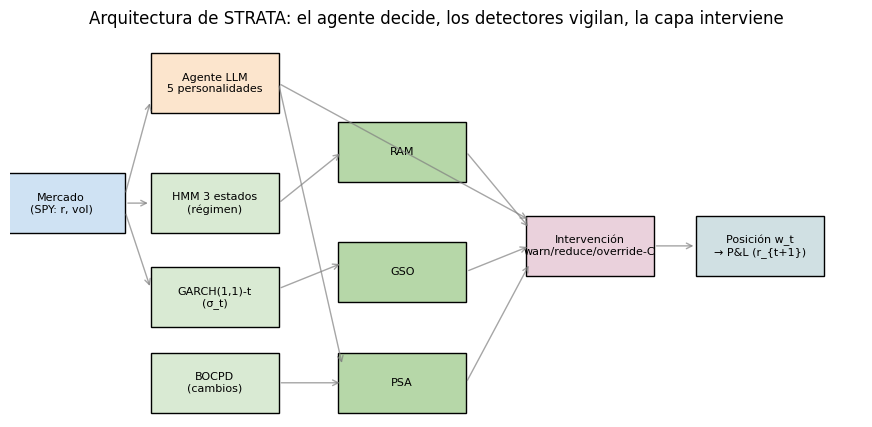

In [1]:
import matplotlib.pyplot as plt

# Diagrama esquemático de STRATA (cajas y flechas; no carga datos).
fig, ax = plt.subplots(figsize=(11, 5)); ax.axis("off")
boxes = [
    ("Mercado\n(SPY: r, vol)", (0.06, 0.50), "#cfe2f3"),
    ("Agente LLM\n5 personalidades", (0.24, 0.78), "#fce5cd"),
    ("HMM 3 estados\n(régimen)", (0.24, 0.50), "#d9ead3"),
    ("GARCH(1,1)-t\n(σ_t)", (0.24, 0.28), "#d9ead3"),
    ("BOCPD\n(cambios)", (0.24, 0.08), "#d9ead3"),
    ("RAM", (0.46, 0.62), "#b6d7a8"),
    ("GSO", (0.46, 0.34), "#b6d7a8"),
    ("PSA", (0.46, 0.08), "#b6d7a8"),
    ("Intervención\nwarn/reduce/override-C", (0.68, 0.40), "#ead1dc"),
    ("Posición w_t\n→ P&L (r_{t+1})", (0.88, 0.40), "#d0e0e3"),
]
for txt, (x, y), c in boxes:
    ax.add_patch(plt.Rectangle((x - 0.075, y - 0.07), 0.15, 0.14, facecolor=c, edgecolor="black"))
    ax.text(x, y, txt, ha="center", va="center", fontsize=8)
arrows = [((0.135, 0.52), (0.165, 0.74)), ((0.135, 0.50), (0.165, 0.50)),
          ((0.135, 0.48), (0.165, 0.30)), ((0.315, 0.50), (0.39, 0.62)),
          ((0.315, 0.30), (0.39, 0.36)), ((0.315, 0.78), (0.39, 0.12)),
          ((0.315, 0.08), (0.39, 0.08)),
          ((0.535, 0.62), (0.61, 0.44)), ((0.535, 0.34), (0.61, 0.40)),
          ((0.535, 0.08), (0.61, 0.36)),
          ((0.315, 0.78), (0.61, 0.46)),  # agente → intervención
          ((0.755, 0.40), (0.805, 0.40))]
for s, e in arrows:
    ax.annotate("", xy=e, xytext=s, arrowprops={"arrowstyle": "->", "color": "grey", "alpha": 0.7})
ax.set_xlim(0, 1); ax.set_ylim(0, 0.9)
ax.set_title("Arquitectura de STRATA: el agente decide, los detectores vigilan, la capa interviene")
plt.show()